# Lyrical Diversity of Lana Del Rey's Albums

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import plotly.express as px
import ast

from lana_nlp.analysis.lyrics_analyzer import LyricsAnalyzer
from lana_nlp.features.vocabulary import VocabularyAnalyzer
from lana_nlp.features.readability import ReadabilityAnalyzer
from lana_nlp.features.sentiment import SentimentAnalyzer

In [2]:
df = pd.read_csv("../data/processed/lyrics.csv")

# make sure nlp_cleaned_lyrics is a list of tokens
df["nlp_cleaned_lyrics"] = (
    df["nlp_cleaned_lyrics"]
    .apply(ast.literal_eval)
)

In [3]:
analyzer = LyricsAnalyzer(
    df,
    basic_text_column="basic_cleaned_lyrics",
    nlp_text_column="nlp_cleaned_lyrics",
)

df = analyzer.analyze()

In [4]:
df["album"].value_counts()

album
Ultraviolence                                          16
Lust for Life                                          16
Did You Know That There's a Tunnel Under Ocean Blvd    16
Sirens                                                 15
Born To Die                                            15
Blue Banisters                                         15
Honeymoon                                              14
Norman Fucking Rockwell!                               14
Lana Del Ray, A.K.A. Lizzy Grant                       13
Chemtrails Over the Country Club                       11
Paradise                                                9
Name: count, dtype: int64

In [5]:
df.head()

,Unnamed: 0,artist,album,song,year,lyrics,basic_cleaned_lyrics,nlp_cleaned_lyrics,word_count,unique_words,syllable_count,line_count,reading_minutes
0,0,Lana Del Rey,Sirens,Drive By,2006,There was a drive-by Sunday night\nMost of us ...,there was a driveby sunday night\nmost of us w...,"[driveby, sunday, night, u, bed, right, turned...",248,97,295,37,1.240
1,1,Lana Del Rey,Sirens,River Road,2006,"Another day is over, another day is done\nAnd ...",another day is over another day is done\nand n...,"[another, day, another, day, done, im, gettin,...",166,64,211,30,0.830
2,2,Lana Del Rey,Sirens,A Star for Nick,2006,"Well, you know it and I know it, I'm gonna be ...",well you know it and i know it im gonna be a s...,"[well, know, know, im, gon, na, star, wont, wo...",84,44,98,15,0.420
3,3,Lana Del Rey,Sirens,My Momma,2006,My momma wouldn't say you were a nice guy\nBut...,my momma wouldnt say you were a nice guy\nbut ...,"[momma, wouldnt, say, nice, guy, youre, 40, jo...",277,114,322,37,1.385
4,4,Lana Del Rey,Sirens,Bad Disease,2006,"Well, there's somethin' about watchin' a crime...",well theres somethin about watchin a crime\nth...,"[well, there, somethin, watchin, crime, make, ...",227,109,268,40,1.135


## Verbosity

In [6]:
album_verbosity = (
    df.groupby("album")["word_count"]
      .agg(["mean", "median", "std", "min", "max"])
      .sort_values("mean", ascending=False)
)

album_verbosity

,mean,median,std,min,max
album,,,,,
Born To Die,403.866667,395.0,95.279938,254,600
Did You Know That There's a Tunnel Under Ocean Blvd,377.437500,338.5,159.657537,188,749
Lust for Life,357.562500,354.0,105.496900,207,613
Norman Fucking Rockwell!,332.285714,313.0,87.776314,196,478
Chemtrails Over the Country Club,310.545455,317.0,65.223253,171,402
Blue Banisters,279.266667,293.0,106.346782,0,436
Paradise,277.777778,290.0,85.467505,90,408
Ultraviolence,273.062500,263.5,73.589373,126,395
Honeymoon,270.285714,270.0,89.534204,84,411


In [7]:
fig = px.box(
    df,
    x="album",
    y="word_count",
    points="all",
    labels={
        "album": "Album",
        "word_count": "Words per Song"
    },
    title="Song Length by Album"
)

fig.update_xaxes(categoryorder="median descending")

fig.show()

In [8]:
album_mean_words = (
    df.groupby("album")["word_count"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    album_mean_words,
    x="album",
    y="word_count",
    labels={
        "album": "Album",
        "word_count": "Average Words per Song"
    },
    title="Average Song Length by Album"
)

fig.show()

## Vocabulary Diversity

In [9]:
df["lexical_diversity"] = df["basic_cleaned_lyrics"].apply(
    lambda lyrics: VocabularyAnalyzer(
        pd.DataFrame({"lyrics": [lyrics]}),
    ).lexical_diversity()
)

album_lexical_diversity = (
    df.groupby(["album", "year"])["lexical_diversity"]
      .mean()
      .reset_index()
      .sort_values("year")
)

album_lexical_diversity

,album,year,lexical_diversity
9,Sirens,2006,0.448389
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,0.331431
8,Paradise,2012,0.370428
1,Born To Die,2012,0.330716
10,Ultraviolence,2014,0.352283
4,Honeymoon,2015,0.376327
6,Lust for Life,2016,0.344481
7,Norman Fucking Rockwell!,2019,0.363967
0,Blue Banisters,2021,0.356637
2,Chemtrails Over the Country Club,2021,0.363920


In [10]:
fig = px.box(
    df,
    x="album",
    y="lexical_diversity",
    points="all",
    labels={
        "album": "Album",
        "lexical_diversity": "Lexical Diversity"
    },
    title="Lexical Diversity by Album"
)

fig.update_xaxes(categoryorder="median descending")

fig.show()

In [11]:
album_mean_words = (
    df.groupby("album")["lexical_diversity"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    album_lexical_diversity,
    x="album",
    y="lexical_diversity",
    labels={
        "album": "Album",
        "lexical_diversity": "Average Lexical Diversity"
    },
    title="Average Lexical Diversity by Album"
)

fig.show()

Sirens has a greater lyrical diversity than all other albums. This could just mean her albums were more thematic after Sirens.

## Readability

In [12]:
readability_analyzer = ReadabilityAnalyzer(
    df,
    text_column="basic_cleaned_lyrics",
)

readability_analyzer.analyze()

readability_by_album = (
    df.groupby(["album", "year"])["flesch_reading_ease"]
      .mean()
      .reset_index()
      .sort_values("year")
)

readability_by_album

,album,year,flesch_reading_ease
9,Sirens,2006,-106.613757
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,-138.002384
8,Paradise,2012,-181.434987
1,Born To Die,2012,-307.817780
10,Ultraviolence,2014,-175.724151
4,Honeymoon,2015,-174.151093
6,Lust for Life,2016,-260.665124
7,Norman Fucking Rockwell!,2019,-233.851884
0,Blue Banisters,2021,-186.915672
2,Chemtrails Over the Country Club,2021,-210.751192


In [13]:
fig = px.box(
    df,
    x="album",
    y="flesch_reading_ease",
    points="all",
    labels={
        "album": "Album",
        "flesch_reading_ease": "Flesch Reading Ease"
    },
    title="Readability by Album"
)

fig.update_xaxes(categoryorder="median descending")

fig.show()

In [14]:
readability_by_album = (
    df.groupby("album")["flesch_reading_ease"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fig = px.bar(
    readability_by_album,
    x="album",
    y="flesch_reading_ease",
    labels={
        "album": "Album",
        "flesch_reading_ease": "Flesch Reading Ease"
    },
    title="Average Flesch Reading Ease by Album"
)

fig.show()

## Positive and Negative Language

In [15]:
sentiment_analyzer = SentimentAnalyzer(
    df,
    text_column="nlp_cleaned_lyrics",
)

sentiment_analyzer.analyze()

sentiment_data = (
    sentiment_analyzer.df
    .groupby(["album", "year"])[
        ["positive_word_ratio", "negative_word_ratio"]
    ]
    .mean()
    .reset_index()
)

sentiment_data = sentiment_data.sort_values("year")

sentiment_data = sentiment_data.melt(
    id_vars=["album", "year"],
    value_vars=["positive_word_ratio", "negative_word_ratio"],
    var_name="sentiment",
    value_name="word_ratio",
)

sentiment_data["sentiment"] = (
    sentiment_data["sentiment"]
    .str.replace("_word_ratio", "", regex=False)
    .str.capitalize()
)

sentiment_data

,album,year,sentiment,word_ratio
0,Sirens,2006,Positive,0.073268
1,"Lana Del Ray, A.K.A. Lizzy Grant",2010,Positive,0.123394
2,Paradise,2012,Positive,0.164628
3,Born To Die,2012,Positive,0.133185
4,Ultraviolence,2014,Positive,0.140005
5,Honeymoon,2015,Positive,0.125119
6,Lust for Life,2016,Positive,0.120989
7,Norman Fucking Rockwell!,2019,Positive,0.119634
8,Blue Banisters,2021,Positive,0.105961
9,Chemtrails Over the Country Club,2021,Positive,0.128633


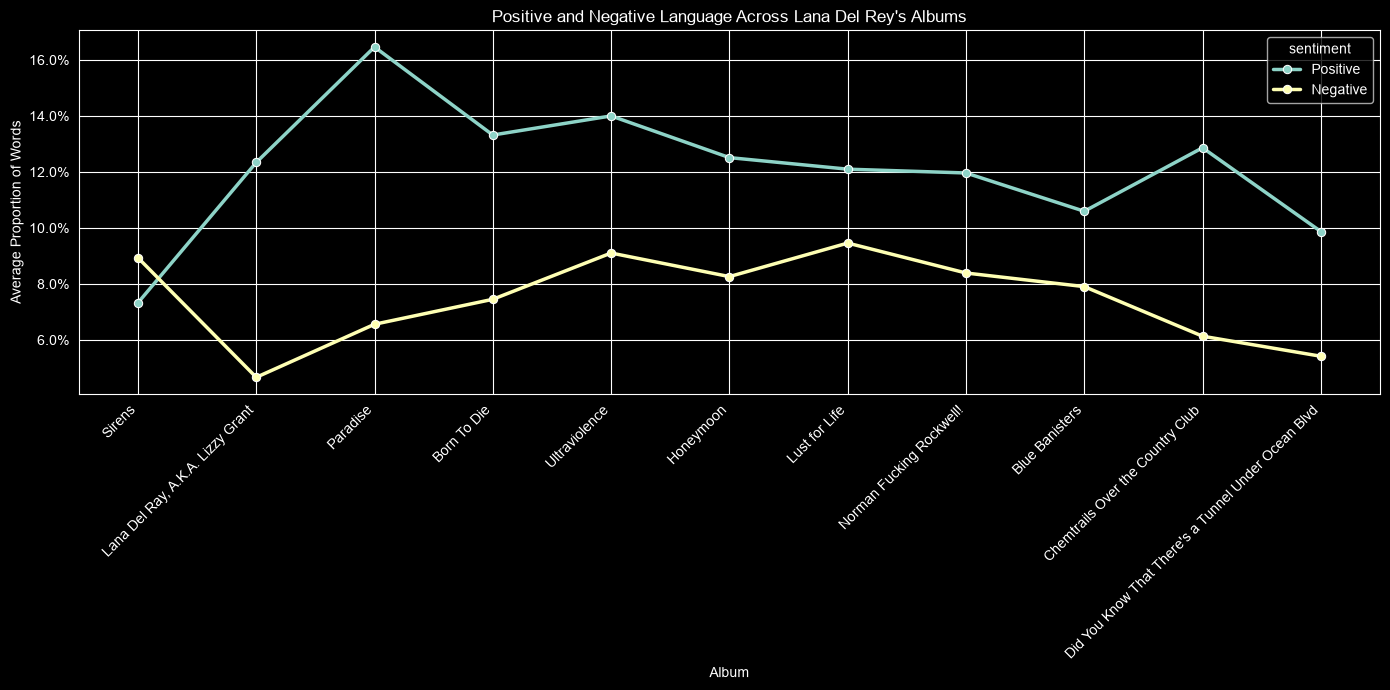

In [16]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=sentiment_data,
    x="album",
    y="word_ratio",
    hue="sentiment",
    marker="o",
    linewidth=2.5,
)

plt.title("Positive and Negative Language Across Lana Del Rey's Albums")
plt.xlabel("Album")
plt.ylabel("Average Proportion of Words")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Emotional Tone

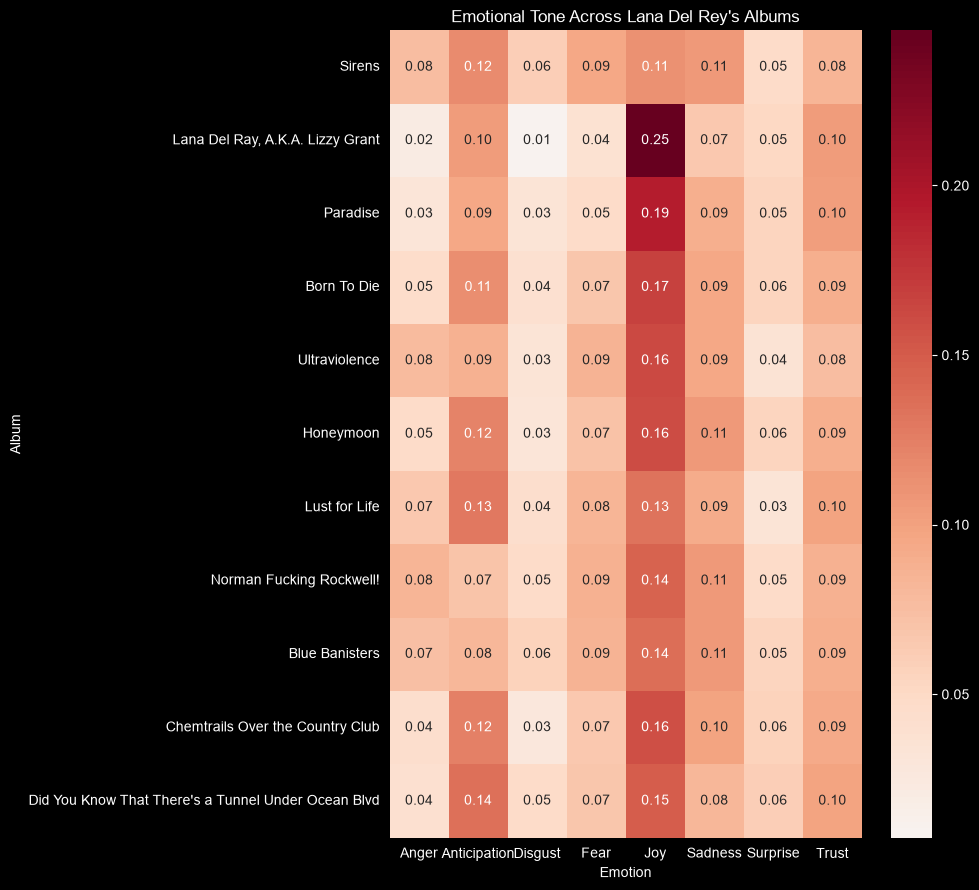

In [17]:
album_order = (
    sentiment_analyzer.df[["album", "year"]]
    .drop_duplicates()
    .sort_values("year")
    ["album"]
    .tolist()
)

emotion_columns = [
    "emotion_Anger",
    "emotion_Anticipation",
    "emotion_Disgust",
    "emotion_Fear",
    "emotion_Joy",
    "emotion_Sadness",
    "emotion_Surprise",
    "emotion_Trust",
]

emotion_by_album = (
    sentiment_analyzer.df.groupby(["album", "year"])[emotion_columns]
      .mean()
      .reset_index()
      .sort_values("year")
)

heatmap_data = emotion_by_album.set_index("album")[emotion_columns]

heatmap_data.columns = [
    col.replace("emotion_", "").capitalize()
    for col in heatmap_data.columns
]

plt.figure(figsize=(10, 9))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)

plt.title("Emotional Tone Across Lana Del Rey's Albums")
plt.xlabel("Emotion")
plt.ylabel("Album")

plt.tight_layout()
plt.show()